# Problem Statement

The UCI News Aggregator dataset is a set of over 420,000 news articles that were compiled in 2014.  

Our goal for this analysis is to determine underlying trends among the articles to uncover commonalities and other links within the dataset using K-nearest neighbors, a machine learning technique that's usually used in analyzing unlabeled data.  However, in this case, it will be used to aid in further exploring the UCI News Aggregator dataset to uncover trends that we may not notice otherwise.

# Dictionary

- ID: the numeric ID of the article
- TITLE: the headline of the article
- URL: the URL of the article
- PUBLISHER: the publisher of the article
- CATEGORY: the category of the news item; one of:
    - e: entertainment
    - b: business
    - t: science and technology
    - m: health
- STORY: alphanumeric ID of the news story that the article discusses
- HOSTNAME: hostname where the article was posted
- TIMESTAMP: approximate timestamp of the article's publication, given in Unix time (seconds since midnight on Jan 1, 1970)

# Exploration

In the data exploration phase, we will cleanse the data to ensure suitable usage for modelling.

## Library Imports

We will import the NumPy, Pandas, Scikit-Learn Matplotlib, and Seaborn libraries to analyze, model and visualize our data.

Meanwhile, pickle and re will allow us to save our variables and perform internal operations within the system in which we perform this analysis.

In [ ]:
# !pip install seaborn
# !pip install --upgrade pip

In [1]:
# Import the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.feature_extraction.text import CountVectorizer

import pickle

import warnings
warnings.filterwarnings("ignore")

# Import the SentenceBERT model
from sentence_transformers import SentenceTransformer

# Classification model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Post analysis
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

# Import the 3D visualization libraries
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.io as pio

In [2]:
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/'
results_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/'

Mounted at /content/drive


In [ ]:
# Import the datasets
convabuse = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_words_imbalanced.csv')
dynamically_generated_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_words_imbalanced.csv')
mlma_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_words_imbalanced.csv')

In [ ]:
# Preview the convabuse data
convabuse.head()

,annotator_id,prev_agent,prev_user,agent,user,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,Does that question interest you?,because my finger is happy,Why do you say your finger is happy?,do you rember japan,0,0,0,0,0,0,0,0
1,7,Does it please you to believe I am a nobe jocky?,bye bye,Please go on.,do you like it hard,0,0,0,0,0,0,1,0
2,7,Have you tried?,dick,Please go on.,oh what a pickle dear monastery,0,0,0,0,0,0,0,0
3,7,Will you be travelling in Economy Class?,yes,What city will you be flying from?,Sydney,1,0,0,0,0,0,0,0
4,7,Please go on.,Hello.,How do you do. Please state your problem.,how old are you?,0,0,0,0,0,0,0,0


In [ ]:
# Preview the dynamically_generated_hate_speech data
dynamically_generated_hate_speech.head()

,label,text,type,annotator,target_groups,original
0,1.0,dalits are lowlives,0,3,0,1
1,1.0,gay people are a burden to our society,0,3,0,1
2,1.0,Arabs are not welcome,0,18,0,1
3,1.0,I'm not saying we should actually eliminate he...,0,16,0,1
4,1.0,bananas are for black people,0,7,0,1


In [ ]:
# Preview the mlma_hate_speech data
mlma_hate_speech.head()

,tweet,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups
0,صلاة الفجر خير لك من ترديد بول البعير وسبي الن...,1,0,0,0,0,0,0,1,0,0,1,1,0,1
1,صراحة نفسي اشوف ولاد الوسخة اللي قالوا مدرب اج...,0,1,1,1,1,1,0,1,0,1,0,0,0,0
2,طيب! هي متبرجة وعبايتها ملونه وطالعة من بيتهم ...,0,0,0,0,1,0,0,1,0,1,0,0,0,0
3,@user @user انا اوافقك بخصوص السوريين و العراق...,0,0,0,0,1,0,0,0,1,0,1,0,0,1
4,هذه السعودية التي شعبها شعب الخيم و بول البعير...,0,0,0,0,1,0,0,1,0,0,1,0,0,1


How many observations are there?

In [ ]:
len(convabuse)

12577

In [ ]:
len(dynamically_generated_hate_speech)

40937

In [ ]:
len(mlma_hate_speech)

18661

What is a typical statement?

In [ ]:
convabuse['agent'][10000]

'Hi. Thanks for testing. Please choose'

In [ ]:
dynamically_generated_hate_speech['text'][12000]

'Your post is absolutely correct. The more muslims who come to our shores the more we excel due to their knowledge'

In [ ]:
mlma_hate_speech['tweet'][3400]

'@user @user msnbc identified terrorist organization! leftist media well!'

Find the non-English tweets in the MLMA Hate Speech dataset (which are placed before the English tweets).

In [ ]:
arabic_tweets = mlma_hate_speech['tweet'][:3353]
arabic_tweets.tail()

,tweet
3348,@user يمشي بخطا ادارتها قيد من الأمريكان ونهب ...
3349,@user مهما حصل هندوس عليهم شويه الرويبضه بس نخ...
3350,الكلب لا يعض اذن اخوه كذابين خنازير @url
3351,@user لأنه صغير ويكتب في قناة خنازير فلن نقرأ ...
3352,الحريم أجمع افلوس وايفون قديم وواتساب ٢٤ ساعة


In [ ]:
french_tweets = mlma_hate_speech['tweet'][14647:]
french_tweets.head()

,tweet
14647,rt @user personnage ainsi q tte la clique gauc...
14648,@user @user @user bah oui t'as raison l'autre ...
14649,moi j'ai personne à qui m'adresser pour réclam...
14650,@user @user c...est vrai que les anchois sont ...
14651,eh les renois faut se réveiller la @url


In [ ]:
mlma_hate_speech.index[:3353]

RangeIndex(start=0, stop=3353, step=1)

In [ ]:
# Remove the Arabic and French tweets due to a potential lack of training in BERT
mlma_hate_speech_english = mlma_hate_speech.copy()
mlma_hate_speech_english.drop(mlma_hate_speech.index[:3353], inplace=True)
mlma_hate_speech_english.drop(mlma_hate_speech.index[14647:], inplace=True)
mlma_hate_speech_english.tail()

,tweet,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups
14642,@user @user @user Maybe but @user who lied abo...,0,0,0,1,0,1,0,1,0,0,0,1,0,1
14643,@user @user You\u2019re a retard :) x,1,1,0,0,1,1,0,0,1,0,0,1,0,0
14644,(2/2) like no you fucking twat I'm doing damag...,1,1,0,0,1,1,0,1,0,0,0,1,0,1
14645,If your bf is retarded guess what u r 2,1,1,0,0,1,1,0,1,0,0,1,0,0,2
14646,@user whats the ching chong stuff mean,1,1,0,0,1,1,0,1,0,1,0,0,0,2


In [ ]:
# Output mlma_hate_speech_english as a CSV file
mlma_hate_speech_english.to_csv(data_path + 'mlma_hate_speech_english_imbalanced.csv', index=False)

Now, let's check out the proportion of null values in the data.

In [ ]:
convabuse.isnull().sum() / len(convabuse)

,0
annotator_id,0.0
prev_agent,0.0
prev_user,0.0
agent,0.0
user,0.0
bot,0.0
generalised,0.0
individual,0.0
system,0.0
explicit,0.0


In [ ]:
dynamically_generated_hate_speech.isnull().sum() / len(dynamically_generated_hate_speech)

,0
label,0.0
text,0.0
type,0.0
annotator,0.0
target_groups,0.0
original,0.0


In [ ]:
mlma_hate_speech_english.isnull().sum() / len(mlma_hate_speech_english)

,0
tweet,0.0
shock_annotator_sentiment,0.0
anger_annotator_sentiment,0.0
confusion_annotator_sentiment,0.0
sadness_annotator_sentiment,0.0
indifference_annotator_sentiment,0.0
disgust_annotator_sentiment,0.0
fear_annotator_sentiment,0.0
implicit,0.0
explicit,0.0


# Text Column Exploration

## Length of each title (number of words)

As LLMs operate on fixed sequence lengths, any string shorter than x number of words must be padded to reach the max length, which is set when the LLM is trained.

This is also why LLMs may do better than other models in certain tasks.

In [ ]:
# Instantiate a count_tokens function to count the number of tokens in a string
def count_tokens(text):
    # Remove any special characters and split the text into words
    tokens = re.findall(r'\w+', text)
    return len(tokens)

In [ ]:
# Add prev_agent, prev_agent, prev_user, and agent as "text"
convabuse["text"] = convabuse["prev_agent"] + " " + convabuse["prev_user"] + " " + convabuse["agent"] + " " + convabuse["user"]

In [ ]:
# Check the average length of prev_agent values using the count_tokens function and add the length of each title to a new column
convabuse['prev_agent_length'] = convabuse['prev_agent'].apply(count_tokens)

In [ ]:
# Check the average length of prev_user values using the count_tokens function and add the length of each title to a new column
convabuse['prev_user_length'] = convabuse['prev_user'].apply(count_tokens)

In [ ]:
# Check the average length of agent values using the count_tokens function and add the length of each title to a new column
convabuse['agent_length'] = convabuse['agent'].apply(count_tokens)

In [ ]:
# Check the average length of user values using the count_tokens function and add the length of each title to a new column
convabuse['user_length'] = convabuse['user'].apply(count_tokens)

In [ ]:
# Check the average length of text values using the count tokens function and add the length of each title to a new column
convabuse["text_length"] = convabuse["text"].apply(count_tokens)

In [ ]:
convabuse.head()

,annotator_id,prev_agent,prev_user,agent,user,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups,text,prev_agent_length,prev_user_length,agent_length,user_length,text_length
0,7,Does that question interest you?,because my finger is happy,Why do you say your finger is happy?,do you rember japan,0,0,0,0,0,0,0,0,Does that question interest you? because my fi...,5,5,8,4,22
1,7,Does it please you to believe I am a nobe jocky?,bye bye,Please go on.,do you like it hard,0,0,0,0,0,0,1,0,Does it please you to believe I am a nobe jock...,11,2,3,5,21
2,7,Have you tried?,dick,Please go on.,oh what a pickle dear monastery,0,0,0,0,0,0,0,0,Have you tried? dick Please go on. oh what a p...,3,1,3,6,13
3,7,Will you be travelling in Economy Class?,yes,What city will you be flying from?,Sydney,1,0,0,0,0,0,0,0,Will you be travelling in Economy Class? yes W...,7,1,7,1,16
4,7,Please go on.,Hello.,How do you do. Please state your problem.,how old are you?,0,0,0,0,0,0,0,0,Please go on. Hello. How do you do. Please sta...,3,1,8,4,16


In [ ]:
dynamically_generated_hate_speech['text_length'] = dynamically_generated_hate_speech['text'].apply(count_tokens)

In [ ]:
dynamically_generated_hate_speech.head()

,label,text,type,annotator,target_groups,original,text_length
0,1.0,dalits are lowlives,0,3,0,1,3
1,1.0,gay people are a burden to our society,0,3,0,1,8
2,1.0,Arabs are not welcome,0,18,0,1,4
3,1.0,I'm not saying we should actually eliminate he...,0,16,0,1,16
4,1.0,bananas are for black people,0,7,0,1,5


In [ ]:
mlma_hate_speech_english['tweet_length'] = mlma_hate_speech_english['tweet'].apply(count_tokens)

In [ ]:
mlma_hate_speech_english.head()

,tweet,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups,tweet_length
3353,call sis im boy girl still faggot shut,0,0,1,0,0,1,0,1,0,1,0,0,0,2,8
3354,@user @user legit nilas retarded idk,0,1,1,0,0,0,0,1,0,1,0,0,0,1,6
3355,said retard @url,0,0,1,0,0,1,0,1,0,1,0,1,1,1,3
3356,america another 8 years obama's ideology via h...,1,1,0,1,0,1,1,1,0,1,1,1,1,1,15
3357,@user don... fucking made cry twat.,1,0,0,0,0,1,0,1,0,1,0,0,0,1,6


Summarize the title metrics.

In [ ]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(convabuse['prev_agent_length'].min()))
print("Mean title length:", np.round(convabuse['prev_agent_length'].mean()))
print("Maximum title length:", np.round(convabuse['prev_agent_length'].max()))

Minimum title length: 0
Mean title length: 9.0
Maximum title length: 79


In [ ]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(convabuse['prev_user_length'].min()))
print("Mean title length:", np.round(convabuse['prev_user_length'].mean()))
print("Maximum title length:", np.round(convabuse['prev_user_length'].max()))

Minimum title length: 0
Mean title length: 3.0
Maximum title length: 68


In [ ]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(convabuse['agent_length'].min()))
print("Mean title length:", np.round(convabuse['agent_length'].mean()))
print("Maximum title length:", np.round(convabuse['agent_length'].max()))

Minimum title length: 0
Mean title length: 9.0
Maximum title length: 79


In [ ]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(convabuse['user_length'].min()))
print("Mean title length:", np.round(convabuse['user_length'].mean()))
print("Maximum title length:", np.round(convabuse['user_length'].max()))

Minimum title length: 0
Mean title length: 3.0
Maximum title length: 78


In [ ]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(dynamically_generated_hate_speech['text_length'].min()))
print("Mean title length:", np.round(dynamically_generated_hate_speech['text_length'].mean()))
print("Maximum title length:", np.round(dynamically_generated_hate_speech['text_length'].max()))

Minimum title length: 1
Mean title length: 25.0
Maximum title length: 410


In [ ]:
dghs = dynamically_generated_hate_speech

In [ ]:
# Print out the minimum, mean, and maximum length of the title values
print("Minimum title length:", np.round(mlma_hate_speech_english['tweet_length'].min()))
print("Mean title length:", np.round(mlma_hate_speech_english['tweet_length'].mean()))
print("Maximum title length:", np.round(mlma_hate_speech_english['tweet_length'].max()))

Minimum title length: 1
Mean title length: 12.0
Maximum title length: 129


In [ ]:
mlma_hate_speech = mlma_hate_speech_english

Investigate the maximum values in title.

In [ ]:
large_titles_10_convabuse = convabuse[convabuse['prev_agent_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['prev_agent_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['prev_agent_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 2479
Number of titles with more than 20 tokens: 1178


,count
prev_agent_length,
79,29
69,22
66,6
63,3
61,123
53,52
51,2
48,237
47,29


In [ ]:
large_titles_10_convabuse = convabuse[convabuse['prev_user_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['prev_user_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['prev_user_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 418
Number of titles with more than 20 tokens: 101


,count
prev_user_length,
68,3
55,9
49,2
48,2
44,3
42,4
40,3
39,3
33,7


In [ ]:
large_titles_10_convabuse = convabuse[convabuse['agent_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['agent_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['agent_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 2351
Number of titles with more than 20 tokens: 929


,count
agent_length,
79,30
69,9
66,9
63,6
61,121
53,59
51,3
48,317
47,34


In [ ]:
large_titles_10_convabuse = convabuse[convabuse['user_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['user_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['user_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 473
Number of titles with more than 20 tokens: 100


,count
user_length,
78,3
75,3
55,5
54,1
53,3
42,5
40,2
39,5
38,5


In [ ]:
large_titles_10_convabuse = convabuse[convabuse['text_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_convabuse))

large_titles_20_convabuse = convabuse[convabuse['text_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_convabuse))

# Get each length of the titles larger than 20 tokens
large_titles_20_convabuse['text_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 10479
Number of titles with more than 20 tokens: 5042


,count
text_length,
174,5
151,3
150,20
147,3
140,3
139,3
131,3
124,2
123,3


In [ ]:
large_titles_10_dghs = dghs[dghs['text_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_dghs))

large_titles_20_dghs = dghs[dghs['text_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_dghs))

# Get each length of the titles larger than 20 tokens
large_titles_20_dghs['text_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 28540
Number of titles with more than 20 tokens: 16903


,count
text_length,
410,1
408,1
402,1
382,2
367,2
323,1
319,1
316,1
304,1


In [ ]:
large_titles_10_mlma_hate_speech = mlma_hate_speech[mlma_hate_speech['tweet_length'] > 10]
print("Number of titles with more than 10 tokens:", len(large_titles_10_mlma_hate_speech))

large_titles_20_mlma_hate_speech = mlma_hate_speech[mlma_hate_speech['tweet_length'] > 20]
print("Number of titles with more than 20 tokens:", len(large_titles_20_mlma_hate_speech))

# Get each length of the titles larger than 20 tokens
large_titles_20_mlma_hate_speech['tweet_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with more than 10 tokens: 5913
Number of titles with more than 20 tokens: 1551


,count
tweet_length,
129,1
42,1
40,1
39,1
38,3
37,4
36,1
35,2
34,5


Investigate the minimum values in the title.

In [ ]:
small_titles_3_convabuse = convabuse[convabuse['prev_agent_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_convabuse))

small_titles_2_convabuse = convabuse[convabuse['prev_agent_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_convabuse))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_convabuse['prev_agent_length'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 2541
Number of titles with 1 token: 2322


,count
prev_agent_length,
1,2259
0,63


In [ ]:
small_titles_3_convabuse = convabuse[convabuse['prev_user_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_convabuse))

small_titles_2_convabuse = convabuse[convabuse['prev_user_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_convabuse))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_convabuse['prev_user_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_convabuse['prev_user'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 6649
Number of titles with 1 token: 5266


,count
prev_user,
İstanbul,2
zzz,3
yyz,3
yy,3
yuppie,4
yup,15
yttfyj,3
yse,3
you,4


In [ ]:
small_titles_3_convabuse = convabuse[convabuse['agent_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_convabuse))

small_titles_2_convabuse = convabuse[convabuse['agent_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_convabuse))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_convabuse['agent_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_convabuse['agent'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 1755
Number of titles with 1 token: 1501


,count
agent,
so,112
ok,387
_,890
When?,17
Hello!,19
:-),76


In [ ]:
small_titles_3_convabuse = convabuse[convabuse['user_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_convabuse))

small_titles_2_convabuse = convabuse[convabuse['user_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_convabuse))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_convabuse['user_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_convabuse['user'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 6209
Number of titles with 1 token: 4601


,count
user,
☀️,2
İstanbul,3
yyz,3
yup,5
yres,4
you,8
yes?,2
yes.,15
yes!!!!!!!!!!!!!!!!!!,3


In [ ]:
small_titles_3_dghs = dghs[dghs['text_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_dghs))

small_titles_2_dghs = dghs[dghs['text_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_dghs))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_dghs['text_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_dghs['text'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 125
Number of titles with 1 token: 11


,count
text,
motherfucker,1
mcdonalds,1
covid,1
Y0UR3VIL,1
WomensWorld,1
NI883RSR3VIL,1
LMFAO!!!!!!!!!!!,1
Idiot.,1
Fuck,1


In [ ]:
small_titles_3_mlma_hate_speech = mlma_hate_speech[mlma_hate_speech['tweet_length'] < 3]
print("Number of titles with less than 3 tokens:", len(small_titles_3_mlma_hate_speech))

small_titles_2_mlma_hate_speech = mlma_hate_speech[mlma_hate_speech['tweet_length'] < 2]
print("Number of titles with 1 token:", len(small_titles_2_mlma_hate_speech))

# Get each length of the titles with only 1 token and the title itself
small_titles_2_mlma_hate_speech['tweet_length'].value_counts().sort_index(ascending=False).head(10)

# Get the titles with only 1 token
small_titles_2_mlma_hate_speech['tweet'].value_counts().sort_index(ascending=False).head(10)

Number of titles with less than 3 tokens: 183
Number of titles with 1 token: 26


,count
tweet,
tweet,1
twat.,2
twat,1
shitnpissnfuckncuntncocksuckernmotherfuckerntits,1
retarded,2
retard?,1
retard,3
negro,2
mongol,1


# Check Special Characters

How many observations have special characters?

In [ ]:
def check_for_special_chars(data):
    """
    Check for special characters in the title column of the DataFrame.
    """
    return data.isalnum()

In [ ]:
# Check for the presence of special characters
convabuse["special_characters"] = convabuse["prev_agent"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
convabuse["special_characters"].sum()

np.int64(501)

In [ ]:
# Check for the presence of special characters
convabuse["special_characters"] = convabuse["prev_user"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
convabuse["special_characters"].sum()

np.int64(4016)

In [ ]:
# Check for the presence of special characters
convabuse["special_characters"] = convabuse["agent"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
convabuse["special_characters"].sum()

np.int64(499)

In [ ]:
# Check for the presence of special characters
convabuse["special_characters"] = convabuse["user"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
convabuse["special_characters"].sum()

np.int64(4206)

In [ ]:
# Check for the presence of special characters
dghs["special_characters"] = dghs["text"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
dghs["special_characters"].sum()

np.int64(8)

In [ ]:
# Check for the presence of special characters
mlma_hate_speech["special_characters"] = mlma_hate_speech["tweet"].apply(check_for_special_chars)

# Check for the sum of observations with special characters
mlma_hate_speech["special_characters"].sum()

np.int64(16)

Now, let's remove these special characters.

In [ ]:
# Change ' to \' to avoid issues
def change_quotes(data):
    """
    Change ' to \' in the title column of the DataFrame.
    """
    return data.replace('\'', '\\\'')

In [ ]:
# Remove special characters from the title column
convabuse["prev_agent"] = convabuse["prev_agent"].apply(change_quotes)

In [ ]:
# Remove special characters from the title column
convabuse["prev_user"] = convabuse["prev_user"].apply(change_quotes)

In [ ]:
# Remove special characters from the title column
convabuse["agent"] = convabuse["agent"].apply(change_quotes)

In [ ]:
# Remove special characters from the title column
convabuse["user"] = convabuse["user"].apply(change_quotes)

In [ ]:
# Remove special characters from the title column
dghs["text"] = dghs["text"].apply(change_quotes)

In [ ]:
# Remove special characters from the title column
mlma_hate_speech["tweet"] = mlma_hate_speech["tweet"].apply(change_quotes)

In [ ]:
# Output convabuse_sa.csv
convabuse.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_sa_punc_imbalanced.csv", index=False)

In [ ]:
# Output dghs_sa.csv
dghs.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dghs_sa_punc_imbalanced.csv", index=False)

In [ ]:
# Output mlma_hate_speech_sa.csv
mlma_hate_speech.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/mlma_hate_speech_sa_punc_imbalanced.csv", index=False)

# Check Word Frequency

Get the 20 most frequent words.

In [ ]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
convabuse_prev_agent_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
convabuse_prev_agent_dtm = convabuse_prev_agent_cv.fit_transform(convabuse['prev_agent'])

# Get the feature names (words) from the CountVectorizer
convabuse_prev_agent_words = np.array(convabuse_prev_agent_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
convabuse_prev_agent_frequencies = convabuse_prev_agent_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
convabuse_prev_agent_index = np.argsort(convabuse_prev_agent_frequencies)[::-1][:20]
print(list(zip(convabuse_prev_agent_words[convabuse_prev_agent_index], convabuse_prev_agent_frequencies[convabuse_prev_agent_index])))

# Create a DataFrame with the words and their frequencies
convabuse_prev_agent_word_freq = pd.DataFrame.from_records({'word': convabuse_prev_agent_words[convabuse_prev_agent_index], 'frequency': convabuse_prev_agent_frequencies[convabuse_prev_agent_index]})
convabuse_prev_agent_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
convabuse_prev_agent_data = dict(zip(convabuse_prev_agent_word_freq['word'].tolist(), convabuse_prev_agent_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in convabuse_prev_agent_data.items():
    print(f"{word}: {freq}")

[('you', np.int64(9822)), ('please', np.int64(2359)), ('to', np.int64(2324)), ('are', np.int64(2291)), ('can', np.int64(2268)), ('on', np.int64(2231)), ('be', np.int64(2158)), ('that', np.int64(2117)), ('go', np.int64(1675)), ('will', np.int64(1592)), ('flying', np.int64(1565)), ('your', np.int64(1357)), ('offsets', np.int64(1322)), ('and', np.int64(1293)), ('do', np.int64(1221)), ('what', np.int64(1220)), ('sure', np.int64(1197)), ('in', np.int64(1193)), ('not', np.int64(1188)), ('take', np.int64(1096))]
9822: you
2359: please
2324: to
2291: are
2268: can
2231: on
2158: be
2117: that
1675: go
1592: will
1565: flying
1357: your
1322: offsets
1293: and
1221: do
1220: what
1197: sure
1193: in
1188: not
1096: take


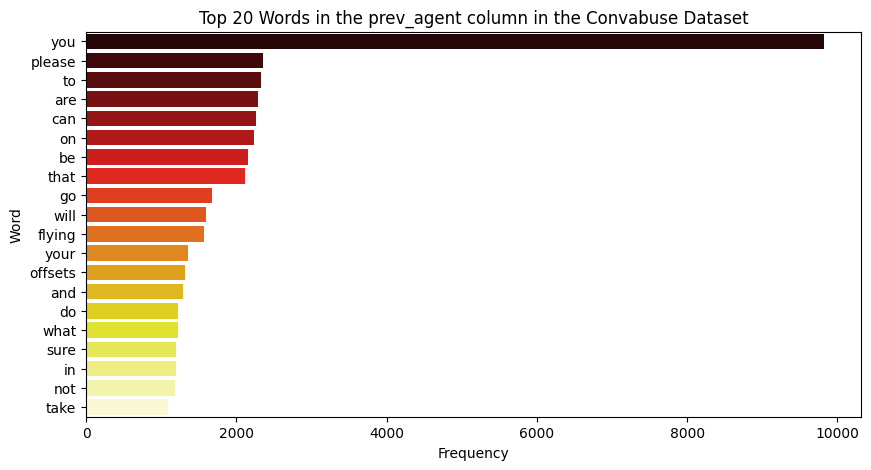

In [ ]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=convabuse_prev_agent_word_freq.head(20), palette='hot', hue='frequency')
plt.title('Top 20 Words in the prev_agent column in the Convabuse Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [ ]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
convabuse_prev_user_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
convabuse_prev_user_dtm = convabuse_prev_user_cv.fit_transform(convabuse['prev_user'])

# Get the feature names (words) from the CountVectorizer
convabuse_prev_user_words = np.array(convabuse_prev_user_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
convabuse_prev_user_frequencies = convabuse_prev_user_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
convabuse_prev_user_index = np.argsort(convabuse_prev_user_frequencies)[::-1][:20]
print(list(zip(convabuse_prev_user_words[convabuse_prev_user_index], convabuse_prev_user_frequencies[convabuse_prev_user_index])))

# Create a DataFrame with the words and their frequencies
convabuse_prev_user_word_freq = pd.DataFrame.from_records({'word': convabuse_prev_user_words[convabuse_prev_user_index], 'frequency': convabuse_prev_user_frequencies[convabuse_prev_user_index]})
convabuse_prev_user_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
convabuse_prev_user_data = dict(zip(convabuse_prev_user_word_freq['word'].tolist(), convabuse_prev_user_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in convabuse_prev_user_data.items():
    print(f"{word}: {freq}")

[('you', np.int64(2471)), ('yes', np.int64(1418)), ('to', np.int64(893)), ('are', np.int64(826)), ('no', np.int64(788)), ('what', np.int64(703)), ('me', np.int64(687)), ('is', np.int64(651)), ('do', np.int64(623)), ('my', np.int64(533)), ('fuck', np.int64(533)), ('how', np.int64(408)), ('it', np.int64(392)), ('can', np.int64(371)), ('your', np.int64(368)), ('the', np.int64(366)), ('that', np.int64(340)), ('am', np.int64(335)), ('want', np.int64(327)), ('not', np.int64(321))]
2471: you
1418: yes
893: to
826: are
788: no
703: what
687: me
651: is
623: do
533: fuck
408: how
392: it
371: can
368: your
366: the
340: that
335: am
327: want
321: not


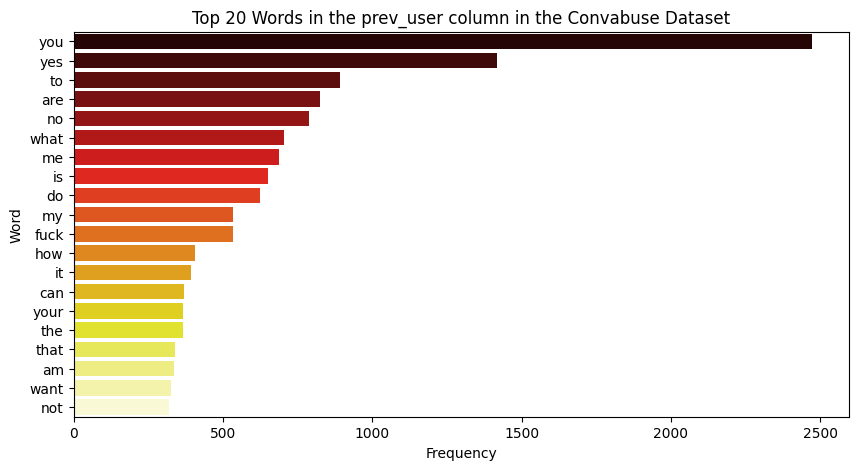

In [ ]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=convabuse_prev_user_word_freq.head(20), palette='hot', hue='frequency')
plt.title('Top 20 Words in the prev_user column in the Convabuse Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [ ]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
convabuse_agent_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
convabuse_agent_dtm = convabuse_agent_cv.fit_transform(convabuse['agent'])

# Get the feature names (words) from the CountVectorizer
convabuse_agent_words = np.array(convabuse_agent_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
convabuse_agent_frequencies = convabuse_agent_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
convabuse_agent_index = np.argsort(convabuse_agent_frequencies)[::-1][:20]
print(list(zip(convabuse_agent_words[convabuse_agent_index], convabuse_agent_frequencies[convabuse_agent_index])))

# Create a DataFrame with the words and their frequencies
convabuse_agent_word_freq = pd.DataFrame.from_records({'word': convabuse_agent_words[convabuse_agent_index], 'frequency': convabuse_agent_frequencies[convabuse_agent_index]})
convabuse_agent_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
convabuse_agent_data = dict(zip(convabuse_agent_word_freq['word'].tolist(), convabuse_agent_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in convabuse_agent_data.items():
    print(f"{word}: {freq}")

[('you', np.int64(9597)), ('to', np.int64(2689)), ('please', np.int64(2638)), ('on', np.int64(2496)), ('can', np.int64(2229)), ('are', np.int64(2153)), ('that', np.int64(2028)), ('be', np.int64(1954)), ('go', np.int64(1880)), ('will', np.int64(1709)), ('your', np.int64(1705)), ('do', np.int64(1643)), ('flying', np.int64(1390)), ('what', np.int64(1374)), ('not', np.int64(1305)), ('sure', np.int64(1257)), ('city', np.int64(1171)), ('offsets', np.int64(1104)), ('and', np.int64(1048)), ('from', np.int64(1031))]
9597: you
2689: to
2638: please
2496: on
2229: can
2153: are
2028: that
1954: be
1880: go
1709: will
1705: your
1643: do
1390: flying
1374: what
1305: not
1257: sure
1171: city
1104: offsets
1048: and
1031: from


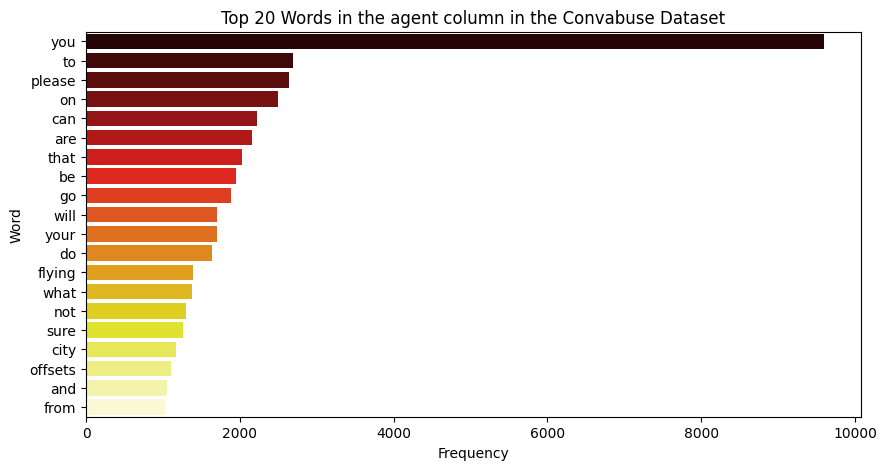

In [ ]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=convabuse_agent_word_freq.head(20), palette='hot', hue='frequency')
plt.title('Top 20 Words in the agent column in the Convabuse Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [ ]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
convabuse_user_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
convabuse_user_dtm = convabuse_user_cv.fit_transform(convabuse['user'])

# Get the feature names (words) from the CountVectorizer
convabuse_user_words = np.array(convabuse_user_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
convabuse_user_frequencies = convabuse_user_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
convabuse_user_index = np.argsort(convabuse_user_frequencies)[::-1][:20]
print(list(zip(convabuse_user_words[convabuse_user_index], convabuse_user_frequencies[convabuse_user_index])))

# Create a DataFrame with the words and their frequencies
convabuse_user_word_freq = pd.DataFrame.from_records({'word': convabuse_user_words[convabuse_user_index], 'frequency': convabuse_user_frequencies[convabuse_user_index]})
convabuse_user_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
convabuse_user_data = dict(zip(convabuse_user_word_freq['word'].tolist(), convabuse_user_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in convabuse_user_data.items():
    print(f"{word}: {freq}")

[('you', np.int64(2636)), ('yes', np.int64(1571)), ('to', np.int64(912)), ('are', np.int64(845)), ('no', np.int64(804)), ('what', np.int64(733)), ('do', np.int64(640)), ('me', np.int64(617)), ('is', np.int64(571)), ('fuck', np.int64(506)), ('my', np.int64(480)), ('the', np.int64(462)), ('it', np.int64(454)), ('how', np.int64(449)), ('am', np.int64(445)), ('that', np.int64(380)), ('not', np.int64(374)), ('have', np.int64(353)), ('can', np.int64(347)), ('your', np.int64(337))]
2636: you
1571: yes
912: to
845: are
804: no
733: what
640: do
617: me
571: is
506: fuck
480: my
462: the
454: it
449: how
445: am
380: that
374: not
353: have
347: can
337: your


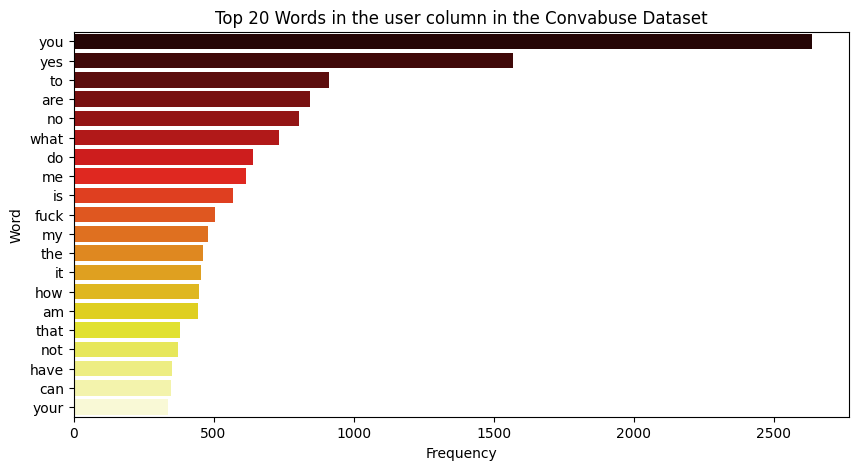

In [ ]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=convabuse_user_word_freq.head(20), palette='hot', hue='frequency')
plt.title('Top 20 Words in the user column in the Convabuse Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [ ]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
dghs_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
dghs_dtm = dghs_cv.fit_transform(dghs['text'])

# Get the feature names (words) from the CountVectorizer
dghs_words = np.array(dghs_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
dghs_frequencies = dghs_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
dghs_index = np.argsort(dghs_frequencies)[::-1][:20]
print(list(zip(dghs_words[dghs_index], dghs_frequencies[dghs_index])))

# Create a DataFrame with the words and their frequencies
dghs_word_freq = pd.DataFrame.from_records({'word': dghs_words[dghs_index], 'frequency': dghs_frequencies[dghs_index]})
dghs_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
dghs_data = dict(zip(dghs_word_freq['word'].tolist(), dghs_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in dghs_data.items():
    print(f"{word}: {freq}")

[('the', np.int64(35142)), ('to', np.int64(27068)), ('and', np.int64(23041)), ('of', np.int64(18547)), ('is', np.int64(15926)), ('are', np.int64(15795)), ('that', np.int64(13507)), ('you', np.int64(13362)), ('it', np.int64(13086)), ('in', np.int64(12696)), ('they', np.int64(12418)), ('be', np.int64(8300)), ('people', np.int64(8236)), ('not', np.int64(7824)), ('for', np.int64(7824)), ('this', np.int64(7259)), ('have', np.int64(6777)), ('all', np.int64(6672)), ('with', np.int64(6616)), ('as', np.int64(5654))]
35142: the
27068: to
23041: and
18547: of
15926: is
15795: are
13507: that
13362: you
13086: it
12696: in
12418: they
8300: be
8236: people
7824: for
7259: this
6777: have
6672: all
6616: with
5654: as


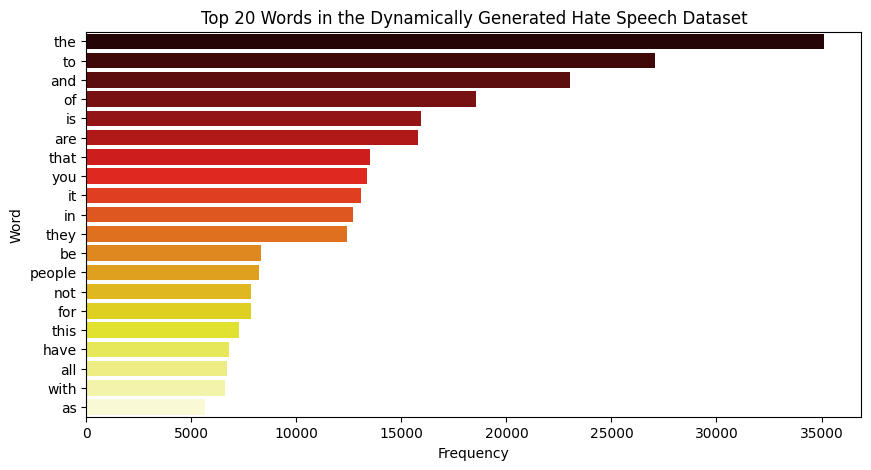

In [ ]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=dghs_word_freq.head(20), palette='hot', hue='frequency')
plt.title('Top 20 Words in the Dynamically Generated Hate Speech Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [ ]:
# Instantiate the CountVectorizer with ngram_range=(1,1), which indicates unigrams
mlma_hate_speech_cv = CountVectorizer(ngram_range=(1,1))

# Create DTM, which means Document Term Matrix, using CountVectorizer
    # The DTM is a matrix representation of the corpus
mlma_hate_speech_dtm = mlma_hate_speech_cv.fit_transform(mlma_hate_speech['tweet'])

# Get the feature names (words) from the CountVectorizer
mlma_hate_speech_words = np.array(mlma_hate_speech_cv.get_feature_names_out())

# Find the 20 most common words in the corpus
mlma_hate_speech_frequencies = mlma_hate_speech_dtm.sum(axis=0).A.flatten()
# Sort the frequencies in descending order and get the indices of the top 20 words
mlma_hate_speech_index = np.argsort(mlma_hate_speech_frequencies)[::-1][:20]
print(list(zip(mlma_hate_speech_words[mlma_hate_speech_index], mlma_hate_speech_frequencies[mlma_hate_speech_index])))

# Create a DataFrame with the words and their frequencies
mlma_hate_speech_word_freq = pd.DataFrame.from_records({'word': mlma_hate_speech_words[mlma_hate_speech_index], 'frequency': mlma_hate_speech_frequencies[mlma_hate_speech_index]})
mlma_hate_speech_word_freq.columns = ['word', 'frequency']

# Get the top 20 words in the corpus
mlma_hate_speech_data = dict(zip(mlma_hate_speech_word_freq['word'].tolist(), mlma_hate_speech_word_freq['frequency'].tolist()))

# Print the top 20 words and their frequencies
for word, freq in mlma_hate_speech_data.items():
    print(f"{word}: {freq}")

[('user', np.int64(8874)), ('url', np.int64(4684)), ('the', np.int64(1868)), ('you', np.int64(1620)), ('to', np.int64(1397)), ('retard', np.int64(1259)), ('retarded', np.int64(1249)), ('and', np.int64(1153)), ('faggot', np.int64(1116)), ('is', np.int64(1101)), ('u2026', np.int64(1082)), ('shithole', np.int64(980)), ('cunt', np.int64(973)), ('twat', np.int64(891)), ('that', np.int64(841)), ('ud83d', np.int64(802)), ('like', np.int64(791)), ('it', np.int64(786)), ('of', np.int64(775)), ('in', np.int64(735))]
8874: user
4684: url
1868: the
1620: you
1397: to
1259: retard
1249: retarded
1153: and
1116: faggot
1101: is
1082: u2026
980: shithole
973: cunt
891: twat
841: that
802: ud83d
791: like
786: it
775: of
735: in


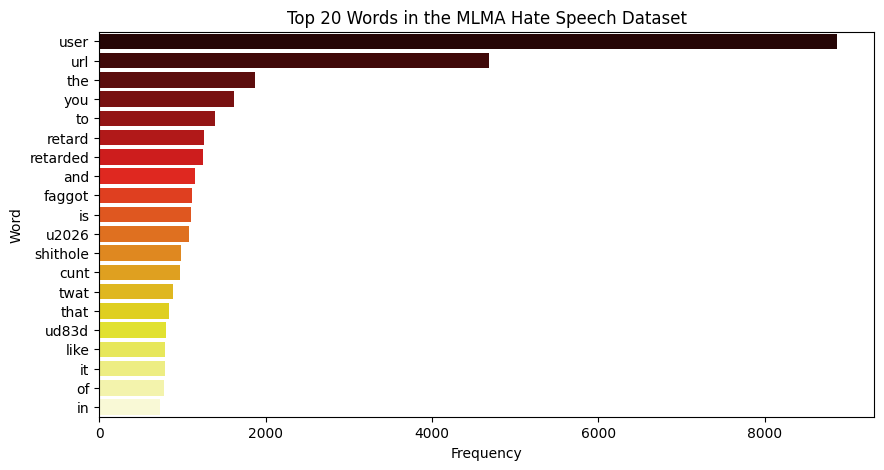

In [ ]:
# Plot a horizontal bar chart of the top 20 words in the , sorted in descending order of frequency
plt.figure(figsize=(10, 5))
sns.barplot(y='frequency', x='word', data=mlma_hate_speech_word_freq.head(20), palette='hot', hue='frequency')
plt.title('Top 20 Words in the MLMA Hate Speech Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()